SEL 1 — Import Library

In [1]:
# ✅ Sel ini sudah lengkap — jalankan tanpa mengubah apapun
import numpy as np
from scipy.linalg import lu_factor, lu_solve
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time

# Pengaturan tampilan
np.set_printoptions(precision=4, suppress=True, linewidth=120)
plt.rcParams.update({'figure.dpi': 110, 'font.family': 'DejaVu Sans'})

print('✅ Import berhasil.')

✅ Import berhasil.


SEL 2 — Data Sistem Kelompok

In [2]:
# ══════════════════════════════════════════════════════════
# ISIAN KELOMPOK 9 (SEED 1009)
# ══════════════════════════════════════════════════════════

SEED_KELOMPOK = 1009
NO_KELOMPOK   = 9

# ---------------------------------------------------------
# DATA BUS
# ---------------------------------------------------------

n_bus = 4

# 0=Slack, 1=PV, 2=PQ
bus_type = np.array([
    0,
    1,
    2,
    2
])

# P Scheduled (p.u.)
P_sch = np.array([
    0.000,
    0.526,
   -0.711,
   -0.454
])

# Q Scheduled (p.u.)
Q_sch = np.array([
    0.000,
    0.000,
   -0.363,
   -0.178
])

# Tegangan awal
V_mag = np.array([
    1.040,
    1.030,
    1.000,
    1.000
])

V_ang = np.zeros(n_bus)

# ---------------------------------------------------------
# DATA SALURAN
# [from,to,R,X,B/2]
# ---------------------------------------------------------

branch_data = np.array([
    [1,2,0.0000,0.0549,0.0000],
    [1,3,0.0190,0.0620,0.0020],
    [2,4,0.0086,0.0407,0.0013],
    [3,4,0.0140,0.0500,0.0023]
],dtype=float)

# ---------------------------------------------------------
# PARAMETER NR
# ---------------------------------------------------------

epsilon  = 1e-4
max_iter = 50

# ---------------------------------------------------------
# SANITY CHECK
# ---------------------------------------------------------

assert None not in P_sch.tolist()
assert None not in Q_sch.tolist()
assert None not in V_mag.tolist()
assert not np.any(np.isnan(branch_data))

print(
    f'✅ Data Kelompok {NO_KELOMPOK} '
    f'(seed={SEED_KELOMPOK}) berhasil diisi.'
)

✅ Data Kelompok 9 (seed=1009) berhasil diisi.


Sel 3 — Tahap 1: Formasi Matriks Y-Bus

In [3]:
def build_ybus(n_bus, branch_data):

    Y = np.zeros((n_bus, n_bus), dtype=complex)

    for branch in branch_data:

        fr = int(branch[0]) - 1
        to = int(branch[1]) - 1

        R = branch[2]
        X = branch[3]
        B_half = branch[4]

        # Admitansi seri
        y_series = 1 / (R + 1j*X)

        # Admitansi shunt
        y_shunt = 1j * B_half

        # Kontribusi ke Y-Bus
        Y[fr, fr] += y_series + y_shunt
        Y[to, to] += y_series + y_shunt

        Y[fr, to] -= y_series
        Y[to, fr] -= y_series

    return Y

Sel 4 — Verifikasi Y-Bus ✅

In [4]:
# ✅ Sel verifikasi ini sudah lengkap — jangan diubah
# Jalankan HANYA setelah build_ybus() Anda tidak ada None/pass lagi

Y_bus = build_ybus(n_bus, branch_data)
G, B  = Y_bus.real, Y_bus.imag

# --- Assert 1: Simetri ---
assert np.allclose(Y_bus, Y_bus.T, atol=1e-10), \
    '❌ Y-Bus TIDAK simetris! Periksa tanda Y[i,j] dan Y[j,i].'

# --- Assert 2: Diagonal positif ---
assert np.all(G.diagonal() > 0), \
    '❌ G_ii ≤ 0! Diagonal Y-Bus harus bernilai real positif.'

# --- Cetak untuk Tabel D.3 ---
print('✅ Y-Bus lolos assert simetri dan G_ii > 0')
print()
print('Isi Tabel Validasi Silang D.3 dengan nilai berikut:')
print(f'  Y₁₁ = {Y_bus[0,0]:.4f}')
print(f'  Y₂₂ = {Y_bus[1,1]:.4f}')
print(f'  Y₃₃ = {Y_bus[2,2]:.4f}')
print(f'  Y₄₄ = {Y_bus[3,3]:.4f}')
print(f'  Y₁₂ = {Y_bus[0,1]:.4f}')
print(f'  Y₁₃ = {Y_bus[0,2]:.4f}')
print()

print(f'  → Cocokkan Y₁₁ dengan slip kelompok Anda. Selisih harus < 0,01%')

✅ Y-Bus lolos assert simetri dan G_ii > 0

Isi Tabel Validasi Silang D.3 dengan nilai berikut:
  Y₁₁ = 4.5184-32.9573j
  Y₂₂ = 4.9698-41.7335j
  Y₃₃ = 9.7113-33.2860j
  Y₄₄ = 10.1627-42.0623j
  Y₁₂ = 0.0000+18.2149j
  Y₁₃ = -4.5184+14.7444j

  → Cocokkan Y₁₁ dengan slip kelompok Anda. Selisih harus < 0,01%


Sel 5 — Tahap 2: Persamaan Daya Injeksi

In [5]:
def calc_power(V_mag, V_ang, G, B):
    """
    Hitung daya aktif P dan reaktif Q di semua bus.
    """

    n = len(V_mag)

    P = np.zeros(n)
    Q = np.zeros(n)

    for i in range(n):
        for j in range(n):

            # Selisih sudut
            theta_ij = V_ang[i] - V_ang[j]

            # Persamaan daya aktif
            P[i] += (
                V_mag[i]
                * V_mag[j]
                * (
                    G[i, j] * np.cos(theta_ij)
                    + B[i, j] * np.sin(theta_ij)
                )
            )

            # Persamaan daya reaktif
            Q[i] += (
                V_mag[i]
                * V_mag[j]
                * (
                    G[i, j] * np.sin(theta_ij)
                    - B[i, j] * np.cos(theta_ij)
                )
            )

    return P, Q

Sel 6 — Mismatch Awal (Flat Start)

In [6]:
# Hitung daya kalkulasi pada kondisi flat start
P_calc_0, Q_calc_0 = calc_power(
    V_mag,
    V_ang,
    G,
    B
)

# ΔP = P_jadwal − P_kalkulasi
dP = P_sch[1:] - P_calc_0[1:]

# ΔQ = Q_jadwal − Q_kalkulasi
dQ = Q_sch[bus_type == 2] - Q_calc_0[bus_type == 2]

# Vektor mismatch lengkap
dF = np.concatenate([dP, dQ])

# Cetak hasil
print('Mismatch flat start:')

print(
    f'  ‖ΔF‖∞ = '
    f'{np.max(np.abs(dF)):.4f} p.u.'
)

print(
    f'  ‖ΔF‖₂ = '
    f'{np.linalg.norm(dF):.4f} p.u.'
)

print(f'  Vektor ΔF = {dF}')

Mismatch flat start:
  ‖ΔF‖∞ = 0.5312 p.u.
  ‖ΔF‖₂ = 0.9211 p.u.
  Vektor ΔF = [ 0.3724 -0.5303 -0.3049  0.2311  0.5312]


Sel 7 — Tahap 3: Matriks Jacobian

In [7]:
def build_jacobian(V_mag, V_ang, G, B, bus_type):

    n = len(V_mag)

    pq_idx = np.where(bus_type == 2)[0]
    non_slack = list(range(1, n))

    P_calc, Q_calc = calc_power(
        V_mag,
        V_ang,
        G,
        B
    )

    n_th = len(non_slack)
    n_pq = len(pq_idx)

    J1 = np.zeros((n_th, n_th))
    J2 = np.zeros((n_th, n_pq))
    J3 = np.zeros((n_pq, n_th))
    J4 = np.zeros((n_pq, n_pq))

    # ==================================================
    # J1 = dP/dθ
    # ==================================================
    for ii, i in enumerate(non_slack):
        for jj, j in enumerate(non_slack):

            t = V_ang[i] - V_ang[j]

            if i != j:

                J1[ii, jj] = (
                    V_mag[i]
                    * V_mag[j]
                    * (
                        G[i, j] * np.sin(t)
                        - B[i, j] * np.cos(t)
                    )
                )

            else:

                J1[ii, jj] = (
                    -Q_calc[i]
                    - B[i, i] * V_mag[i]**2
                )

    # ==================================================
    # J2 = dP/dV
    # ==================================================
    for ii, i in enumerate(non_slack):
        for jj, j in enumerate(pq_idx):

            t = V_ang[i] - V_ang[j]

            if i != j:

                J2[ii, jj] = (
                    V_mag[i]
                    * (
                        G[i, j] * np.cos(t)
                        + B[i, j] * np.sin(t)
                    )
                )

            else:

                J2[ii, jj] = (
                    P_calc[i] / V_mag[i]
                    + G[i, i] * V_mag[i]
                )

    # ==================================================
    # J3 = dQ/dθ
    # ==================================================
    for ii, i in enumerate(pq_idx):
        for jj, j in enumerate(non_slack):

            t = V_ang[i] - V_ang[j]

            if i != j:

                J3[ii, jj] = (
                    -V_mag[i]
                    * V_mag[j]
                    * (
                        G[i, j] * np.cos(t)
                        + B[i, j] * np.sin(t)
                    )
                )

            else:

                J3[ii, jj] = (
                    P_calc[i]
                    - G[i, i] * V_mag[i]**2
                )

    # ==================================================
    # J4 = dQ/dV
    # ==================================================
    for ii, i in enumerate(pq_idx):
        for jj, j in enumerate(pq_idx):

            t = V_ang[i] - V_ang[j]

            if i != j:

                J4[ii, jj] = (
                    V_mag[i]
                    * (
                        G[i, j] * np.sin(t)
                        - B[i, j] * np.cos(t)
                    )
                )

            else:

                J4[ii, jj] = (
                    Q_calc[i] / V_mag[i]
                    - B[i, i] * V_mag[i]
                )

    J = np.block([
        [J1, J2],
        [J3, J4]
    ])

    return J

Sel 8 — Verifikasi Jacobian (Finite Difference) ✅

In [8]:
# ✅ Sel verifikasi — sudah lengkap

def jacobian_numerical(V_mag, V_ang, G, B, bus_type, h=1e-6):

    pq_idx = np.where(bus_type == 2)[0]
    non_slack = list(range(1, n_bus))

    P0, Q0 = calc_power(V_mag, V_ang, G, B)

    f0 = np.concatenate([
        P0[non_slack],
        Q0[pq_idx]
    ])

    n_state = len(non_slack) + len(pq_idx)

    J_num = np.zeros((len(f0), n_state))

    # perturbasi sudut
    for ii, i in enumerate(non_slack):

        Va_p = V_ang.copy()
        Va_p[i] += h

        P_p, Q_p = calc_power(
            V_mag,
            Va_p,
            G,
            B
        )

        fp = np.concatenate([
            P_p[non_slack],
            Q_p[pq_idx]
        ])

        J_num[:, ii] = (fp - f0)/h

    # perturbasi tegangan
    for jj, j in enumerate(pq_idx):

        Vm_p = V_mag.copy()
        Vm_p[j] += h

        P_p, Q_p = calc_power(
            Vm_p,
            V_ang,
            G,
            B
        )

        fp = np.concatenate([
            P_p[non_slack],
            Q_p[pq_idx]
        ])

        J_num[:, len(non_slack)+jj] = (
            fp - f0
        )/h

    return J_num


# =====================================================
# VERIFIKASI JACOBIAN
# =====================================================

J_analytic = build_jacobian(
    V_mag,
    V_ang.copy(),
    G,
    B,
    bus_type
)

J_numerical = jacobian_numerical(
    V_mag,
    V_ang.copy(),
    G,
    B,
    bus_type
)

max_err = np.max(
    np.abs(
        J_analytic - J_numerical
    )
)

print(
    f'Max error Jacobian analitik vs numerik: '
    f'{max_err:.2e}'
)

assert max_err < 1e-4, (
    f'❌ Jacobian SALAH! '
    f'max_err = {max_err:.2e}'
)

print(
    '✅ Jacobian lolos verifikasi finite difference '
    '(max_err < 1e-4)'
)

print('\nJacobian 5×5 pada flat start:')
print(J_analytic)

# =====================================================
# PERTANYAAN F1
# =====================================================

print('\nTabel untuk Pertanyaan F1 — truncation error vs h:')
print(f'{"h":>10}  {"max_err":>12}')

for h_val in [1e-3, 1e-5, 1e-7, 1e-9]:

    J_n = jacobian_numerical(
        V_mag,
        V_ang.copy(),
        G,
        B,
        bus_type,
        h=h_val
    )

    err = np.max(
        np.abs(
            J_analytic - J_n
        )
    )

    print(
        f'{h_val:>10.0e}  '
        f'{err:>12.4e}'
    )

Max error Jacobian analitik vs numerik: 4.21e-05
✅ Jacobian lolos verifikasi finite difference (max_err < 1e-4)

Jacobian 5×5 pada flat start:
[[ 43.7373   0.     -24.2255   0.      -5.1189]
 [  0.      33.8801 -18.546    9.5306  -5.1929]
 [-24.2255 -18.546   42.7715  -5.1929  10.0136]
 [ -0.      -9.892    5.1929  32.692  -18.546 ]
 [  5.1189   5.1929 -10.3118 -18.546   41.3531]]

Tabel untuk Pertanyaan F1 — truncation error vs h:
         h       max_err
     1e-03    4.2062e-02
     1e-05    4.2062e-04
     1e-07    4.1749e-06
     1e-09    9.7785e-06


Sel 9 — Tahap 4 & 5: Loop Newton-Raphson

In [9]:
def newton_raphson(V_mag_init, V_ang_init, Y_bus,
                   P_sch, Q_sch,
                   bus_type,
                   epsilon=1e-4,
                   max_iter=50):

    G = Y_bus.real
    B = Y_bus.imag

    pq_idx = np.where(bus_type == 2)[0]
    non_slack = list(range(1, len(V_mag_init)))

    # copy supaya data awal tidak berubah
    V_mag = V_mag_init.copy()
    V_ang = V_ang_init.copy()

    history_inf = []
    history_2 = []
    cond_history = []

    for iteration in range(max_iter):

        # ==================================================
        # LANGKAH 1
        # Hitung daya kalkulasi
        # ==================================================
        P_calc, Q_calc = calc_power(
            V_mag,
            V_ang,
            G,
            B
        )

        # ==================================================
        # LANGKAH 2
        # Hitung mismatch
        # ==================================================
        dP = (
            P_sch[non_slack]
            -
            P_calc[non_slack]
        )

        dQ = (
            Q_sch[pq_idx]
            -
            Q_calc[pq_idx]
        )

        dF = np.concatenate([
            dP,
            dQ
        ])

        # ==================================================
        # Simpan history
        # ==================================================
        norm_inf = np.max(np.abs(dF))
        norm_2 = np.linalg.norm(dF)

        history_inf.append(norm_inf)
        history_2.append(norm_2)

        print(
            f"  Iter {iteration:2d}: "
            f"‖ΔF‖∞ = {norm_inf:.6e}"
        )

        # ==================================================
        # LANGKAH 3
        # Cek konvergensi
        # ==================================================
        if norm_inf < epsilon:

            print(
                f"  ✅ Konvergen pada iterasi "
                f"{iteration}!"
            )

            break

        # ==================================================
        # LANGKAH 4
        # Bangun Jacobian
        # ==================================================
        J = build_jacobian(
            V_mag,
            V_ang,
            G,
            B,
            bus_type
        )

        cond_history.append(
            np.linalg.cond(J)
        )

        # ==================================================
        # LANGKAH 5
        # Selesaikan J Δx = ΔF
        # ==================================================
        lu, piv = lu_factor(J)

        dx = lu_solve(
            (lu, piv),
            dF
        )

        # ==================================================
        # LANGKAH 6
        # Update state variable
        # ==================================================

        # Δθ2 Δθ3 Δθ4
        V_ang[non_slack] += dx[:len(non_slack)]

        # ΔV3 ΔV4
        V_mag[pq_idx] += dx[len(non_slack):]

    else:

        print(
            f"⚠️ DIVERGEN setelah "
            f"{max_iter} iterasi!"
        )

    return (
        V_mag,
        V_ang,
        history_inf,
        history_2,
        cond_history
    )

Sel 10 — Jalankan NR dan Isi Tabel G.3 ✅ (setelah Sel 9 selesai)

In [10]:
# Jalankan Newton-Raphson
print('═' * 55)
print('Newton-Raphson Power Flow')
print('═' * 55)
t_start = time.perf_counter()

V_mag_sol, V_ang_sol, hist_inf, hist_2, cond_hist = newton_raphson(
    V_mag.copy(), V_ang.copy(), Y_bus, P_sch, Q_sch, bus_type,
    epsilon=epsilon, max_iter=max_iter
)

t_elapsed = time.perf_counter() - t_start
print(f'  Waktu: {t_elapsed*1000:.1f} ms')
print()

# Hasil tegangan akhir
print('Profil tegangan akhir:')
for i in range(n_bus):
    print(f'  Bus {i+1}: |V| = {V_mag_sol[i]:.4f} p.u.  θ = {np.degrees(V_ang_sol[i]):+.4f}°')
print()

# Tabel G.3 — cocokkan dengan slip kelompok Anda
print('Tabel G.3 — Validasi Konvergensi:')
print(f'  {"Iter":>4}  {"‖ΔF‖∞":>12}  {"‖ΔF‖₂":>12}  {"Rasio eₖ₊₁/eₖ²(inf)":>20}  {"cond(J)":>12}')
for k, (ni, n2) in enumerate(zip(hist_inf, hist_2)):
    rasio = hist_inf[k] / hist_inf[k-1]**2 if k > 0 else float('nan')
    cond  = cond_hist[k] if k < len(cond_hist) else float('nan')
    print(f'  {k:>4}  {ni:>12.4e}  {n2:>12.4e}  {rasio:>20.4f}  {cond:>12.2e}')

# Verifikasi: cocokkan |V3| dan |V4| dengan slip
print(f'\n  → |V₃| = {V_mag_sol[2]:.4f}  |V₄| = {V_mag_sol[3]:.4f}')
print(f'  → Cocokkan dengan nilai referensi di slip kelompok Anda (toleransi ±0,01%)')

═══════════════════════════════════════════════════════
Newton-Raphson Power Flow
═══════════════════════════════════════════════════════
  Iter  0: ‖ΔF‖∞ = 5.311968e-01
  Iter  1: ‖ΔF‖∞ = 1.399440e-02
  Iter  2: ‖ΔF‖∞ = 8.577946e-06
  ✅ Konvergen pada iterasi 2!
  Waktu: 19.6 ms

Profil tegangan akhir:
  Bus 1: |V| = 1.0400 p.u.  θ = +0.0000°
  Bus 2: |V| = 1.0300 p.u.  θ = -0.1736°
  Bus 3: |V| = 1.0104 p.u.  θ = -1.6660°
  Bus 4: |V| = 1.0153 p.u.  θ = -1.3589°

Tabel G.3 — Validasi Konvergensi:
  Iter         ‖ΔF‖∞         ‖ΔF‖₂   Rasio eₖ₊₁/eₖ²(inf)       cond(J)
     0    5.3120e-01    9.2110e-01                   nan      6.94e+00
     1    1.3994e-02    2.0336e-02                0.0496      7.06e+00
     2    8.5779e-06    1.2400e-05                0.0438           nan

  → |V₃| = 1.0104  |V₄| = 1.0153
  → Cocokkan dengan nilai referensi di slip kelompok Anda (toleransi ±0,01%)


Sel 11 — Tahap 6: Aliran Daya Saluran

In [11]:
def calc_line_flows(V_mag, V_ang, branch_data):
    """
    Hitung aliran daya kompleks di semua saluran via model-π.

    Model-π untuk saluran i–j:
        I_ij = y_series*(V_i − V_j) + y_shunt*V_i   (arus dari i ke j)
        I_ji = y_series*(V_j − V_i) + y_shunt*V_j   (arus dari j ke i)
        S_ij = V_i * conj(I_ij)                     (daya kompleks i→j)
        S_ji = V_j * conj(I_ji)                     (daya kompleks j→i)
        S_loss = S_ij + S_ji                         (rugi saluran)
    """
    # Tegangan kompleks: V = |V| * e^(jθ)
    V_cx = V_mag * np.exp(1j * V_ang)

    results      = []
    P_loss_total = 0.0

    for branch in branch_data:
        fr, to = int(branch[0]) - 1, int(branch[1]) - 1
        R      = branch[2]
        X      = branch[3]
        B      = branch[4]

        # ══ ISI INI ══  Hitung admitansi seri dan shunt
        y_series = 1.0 / complex(R, X)   # ══ ISI INI ══
        y_shunt  =  1j * (B / 2)  # ══ ISI INI ══

        # ══ ISI INI ══  Hitung arus dan daya kompleks
        I_ij = y_series * (V_cx[fr] - V_cx[to]) + y_shunt * V_cx[fr]   # ══ ISI INI ══
        I_ji = y_series * (V_cx[to] - V_cx[fr]) + y_shunt * V_cx[to]   # ══ ISI INI ══
        S_ij = V_cx[fr] * np.conj(I_ij)   # ══ ISI INI ══
        S_ji = V_cx[to] * np.conj(I_ji)   # ══ ISI INI ══

        S_loss = S_ij + S_ji
        P_loss_total += S_loss.real

        results.append({
            'saluran' : f"{int(branch[0])}-{int(branch[1])}",
            'P_ij_pu' : S_ij.real,
            'Q_ij_pu' : S_ij.imag,
            'P_loss_MW': S_loss.real * 100,
        })

    return results, P_loss_total

Sel 12 — Neraca Daya ✅ (setelah Sel 11 selesai)

In [12]:
flows, P_loss = calc_line_flows(V_mag_sol, V_ang_sol, branch_data)

# Tabel aliran saluran
print(f'  {"Saluran":>8}  {"P_ij (p.u.)":>12}  {"Q_ij (p.u.)":>12}  {"P_loss (MW)":>12}')
print('  ' + '-'*52)
for f in flows:
    print(f"  {f['saluran']:>8}  {f['P_ij_pu']:>12.4f}  {f['Q_ij_pu']:>12.4f}  {f['P_loss_MW']:>12.3f}")

# --- Neraca daya ---
# Opsi A: dari sisi beban (P_beban + P_loss = P_gen_total)
P_beban     = abs(P_sch[2]) + abs(P_sch[3])
P_gen_total = P_beban + P_loss            # Opsi A

# Opsi B: dari sisi pembangkit (uncomment untuk cross-check)
V_cx_sol   = V_mag_sol * np.exp(1j * V_ang_sol)
P_slack    = (V_cx_sol[0] * np.conj((Y_bus @ V_cx_sol)[0])).real
P_gen_total_B = P_slack + P_sch[1]     # harus = Opsi A

efisiensi = P_beban / P_gen_total * 100

print(f'\nNeraca Daya:')
print(f'  P_gen_total = {P_gen_total:.4f} p.u. = {P_gen_total*100:.2f} MW')
print(f'  P_beban     = {P_beban:.4f} p.u. = {P_beban*100:.2f} MW')
print(f'  P_loss      = {P_loss:.4f} p.u. = {P_loss*100:.3f} MW')
print(f'  Efisiensi   = {efisiensi:.2f}%')
print(f'  Selisih neraca = {abs(P_gen_total - P_beban - P_loss):.2e} p.u.  (harus < 1e-4)')

assert abs(P_gen_total - P_beban - P_loss) < 1e-4, '❌ Neraca daya TIDAK seimbang!'
print('✅ Neraca daya seimbang.')
print()
print(f'  → Cocokkan P_loss dan Efisiensi dengan slip kelompok Anda')

   Saluran   P_ij (p.u.)   Q_ij (p.u.)   P_loss (MW)
  ----------------------------------------------------
       1-2        0.0591        0.1895         0.000
       1-3        0.5914        0.3208         0.797
       2-4        0.5851        0.2529         0.330
       3-4       -0.1275       -0.0638         0.028

Neraca Daya:
  P_gen_total = 1.1765 p.u. = 117.65 MW
  P_beban     = 1.1650 p.u. = 116.50 MW
  P_loss      = 0.0115 p.u. = 1.154 MW
  Efisiensi   = 99.02%
  Selisih neraca = 0.00e+00 p.u.  (harus < 1e-4)
✅ Neraca daya seimbang.

  → Cocokkan P_loss dan Efisiensi dengan slip kelompok Anda


Sel 13 — 4 Plot Wajib ✅

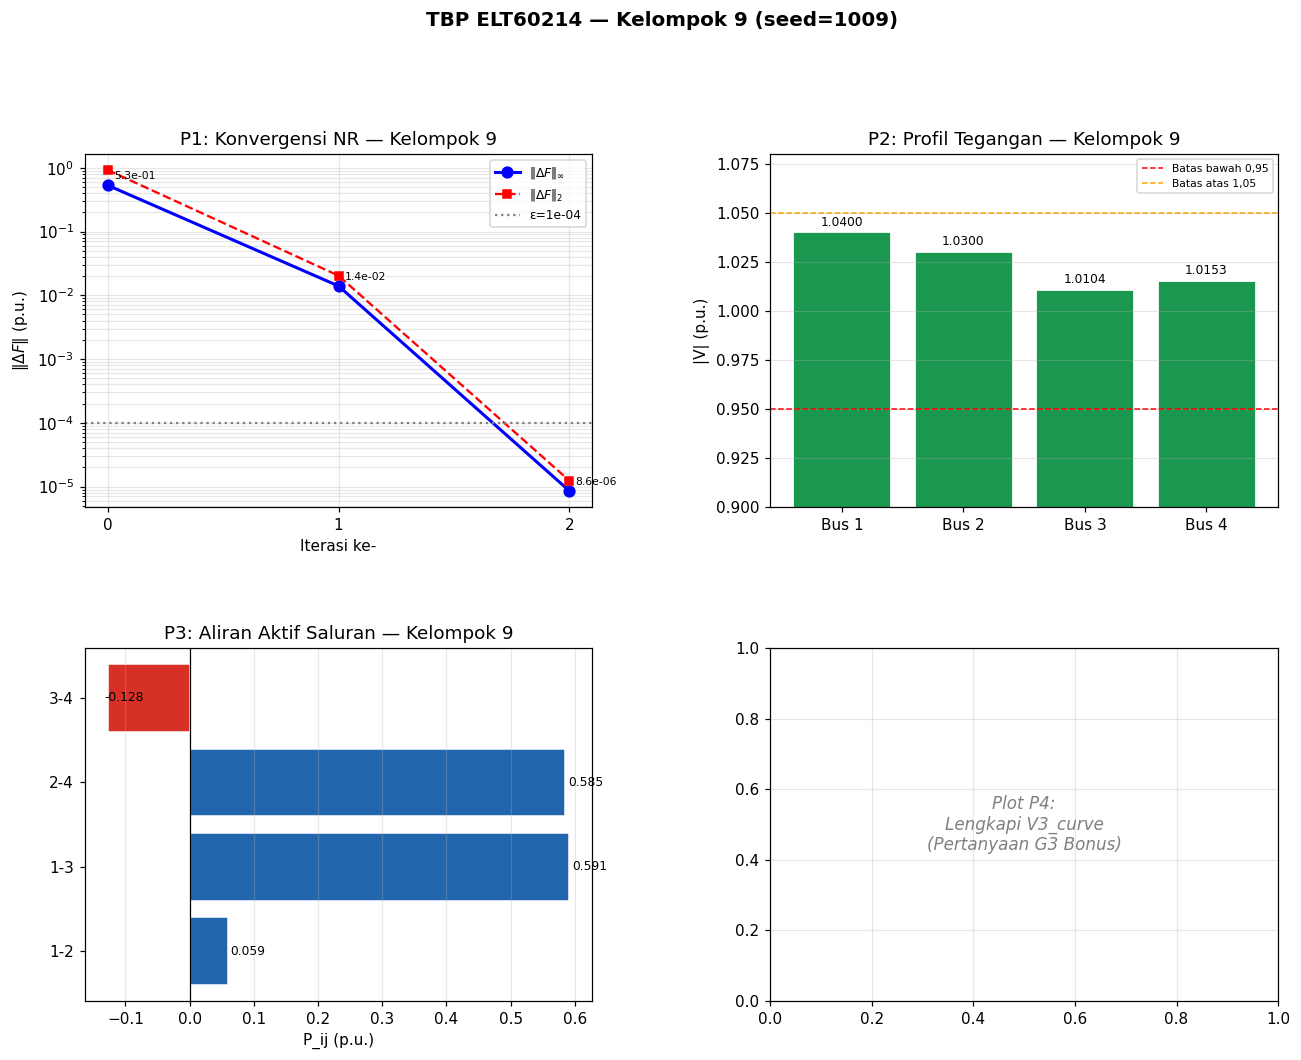

✅ 3 plot wajib tersimpan. Plot P4 aktifkan setelah mengisi V3_curve.


In [13]:
fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.40, wspace=0.35)

# ── Plot P1: Konvergensi NR (semi-log) ──────────────────────
ax1 = fig.add_subplot(gs[0, 0])
iters = range(len(hist_inf))
ax1.semilogy(iters, hist_inf, 'bo-', lw=2, ms=7, label=r'$\|\Delta F\|_\infty$')
ax1.semilogy(iters, hist_2,   'rs--',lw=1.5,ms=5,label=r'$\|\Delta F\|_2$')
ax1.axhline(epsilon, color='gray', ls=':', lw=1.5, label=f'ε={epsilon:.0e}')
for k, v in enumerate(hist_inf):
    ax1.annotate(f'{v:.1e}', (k, v), xytext=(4,4), textcoords='offset points', fontsize=7)
ax1.set_xlabel('Iterasi ke-'); ax1.set_ylabel(r'$\|\Delta F\|$ (p.u.)')
ax1.set_title(f'P1: Konvergensi NR — Kelompok {NO_KELOMPOK}'); ax1.legend(fontsize=8)
ax1.grid(True, which='both', alpha=0.3); ax1.set_xticks(list(iters))

# ── Plot P2: Profil Tegangan ─────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
bus_labels = [f'Bus {i+1}' for i in range(n_bus)]
colors_bus = ['#1a9850' if 0.95<=v<=1.05 else '#d73027' for v in V_mag_sol]
bars = ax2.bar(bus_labels, V_mag_sol, color=colors_bus, edgecolor='white', lw=0.5)
ax2.axhline(0.95, color='red', ls='--', lw=1, label='Batas bawah 0,95')
ax2.axhline(1.05, color='orange', ls='--', lw=1, label='Batas atas 1,05')
for bar, v in zip(bars, V_mag_sol):
    ax2.text(bar.get_x()+bar.get_width()/2, v+0.002, f'{v:.4f}',
             ha='center', va='bottom', fontsize=8)
ax2.set_ylim(0.90, 1.08); ax2.set_ylabel('|V| (p.u.)')
ax2.set_title(f'P2: Profil Tegangan — Kelompok {NO_KELOMPOK}'); ax2.legend(fontsize=7)
ax2.grid(axis='y', alpha=0.3)

# ── Plot P3: Aliran Daya Saluran ─────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
sal_labels = [f["saluran"] for f in flows]
p_vals     = [f["P_ij_pu"] for f in flows]
colors_sal = ['#2166ac' if p>=0 else '#d73027' for p in p_vals]
ax3.barh(sal_labels, p_vals, color=colors_sal, edgecolor='white')
ax3.axvline(0, color='black', lw=0.8)
for i, v in enumerate(p_vals):
    ax3.text(v + 0.005*np.sign(v) if v else 0.005, i, f'{v:.3f}', va='center', fontsize=8)
ax3.set_xlabel('P_ij (p.u.)'); ax3.set_title(f'P3: Aliran Aktif Saluran — Kelompok {NO_KELOMPOK}')
ax3.grid(axis='x', alpha=0.3)

# ── Plot P4: Kurva Q-V Bus 3 ────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
# ══ ISI INI ══  Generate data kurva Q-V (Pertanyaan G3 Bonus)
# Petunjuk: loop Q3_range, jalankan newton_raphson() untuk tiap nilai,
# kumpulkan V3_konvergen ke list, plot dengan ax4
# Ganti placeholder di bawah dengan kurva aktual Anda:
Q3_range_plot = np.arange(0.3, 8.5, 0.5)
V3_curve      = [None] * len(Q3_range_plot)  # ══ ISI INI ══

# (setelah V3_curve terisi, uncomment 4 baris berikut)
# ax4.plot(Q3_range_plot, V3_curve, 'b-o', ms=5, lw=1.5)
# ax4.axhline(0.95, color='red', ls='--', lw=1, label='|V|=0,95 (kritis)')
# ax4.set_xlabel('Q₃ jadwal (p.u.)'); ax4.set_ylabel('|V₃| konvergen (p.u.)')
# ax4.set_title(f'P4: Kurva Q-V Bus 3 — Kelompok {NO_KELOMPOK}'); ax4.legend(fontsize=8)
ax4.text(0.5, 0.5, 'Plot P4:\nLengkapi V3_curve\n(Pertanyaan G3 Bonus)',
         ha='center', va='center', transform=ax4.transAxes,
         fontsize=11, color='gray', style='italic')
ax4.grid(alpha=0.3)

plt.suptitle(f'TBP ELT60214 — Kelompok {NO_KELOMPOK} (seed={SEED_KELOMPOK})',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig(f'TBP_plots_kelompok{NO_KELOMPOK}.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 3 plot wajib tersimpan. Plot P4 aktifkan setelah mengisi V3_curve.')

## **Sel 14 — Jawaban Pertanyaan Analisis**

Pertanyaan E1 — ✅ WAJIB

In [14]:
# === Pertanyaan E1 ===
# Flat Start — Bus mana ‖ΔF‖ terbesar? Jelaskan secara fisis.

V_mag_flat = np.array([1.040, 1.030, 1.000, 1.000])
V_ang_flat = np.zeros(4)

G, B = Y_bus.real, Y_bus.imag

# Indeks yang digunakan pada Newton-Raphson
non_slack = list(range(1, n_bus))      # Bus 2,3,4
pq_idx    = np.where(bus_type == 2)[0] # Bus 3,4

# Hitung daya pada kondisi flat start
P_calc_flat, Q_calc_flat = calc_power(
    V_mag_flat,
    V_ang_flat,
    G,
    B
)

# Hitung ΔP dan ΔQ per bus
dP_flat = P_sch[non_slack] - P_calc_flat[non_slack]
dQ_flat = Q_sch[pq_idx]    - Q_calc_flat[pq_idx]

dF_flat = np.concatenate([dP_flat, dQ_flat])

# Label tiap elemen vektor mismatch
labels = [
    'ΔP_bus2',
    'ΔP_bus3',
    'ΔP_bus4',
    'ΔQ_bus3',
    'ΔQ_bus4'
]

bus_ref = [2, 3, 4, 3, 4]

print("=== Pertanyaan E1 ===")

print("\nMismatch tiap elemen pada Flat Start:")
print(f"{'Elemen':>10} | {'Nilai (p.u.)':>14} | {'|Nilai|':>10}")
print("-"*42)

for lab, val in zip(labels, dF_flat):
    print(
        f"{lab:>10} | "
        f"{val:>14.6f} | "
        f"{abs(val):>10.6f}"
    )

# Cari elemen mismatch terbesar
idx_max = np.argmax(np.abs(dF_flat))

print(f"\n‖ΔF‖∞ = {np.max(np.abs(dF_flat)):.6f} p.u.")
print(f"→ Elemen terbesar : {labels[idx_max]}")
print(f"→ Nilai           : {dF_flat[idx_max]:.6f} p.u.")
print(f"→ Terjadi di      : Bus {bus_ref[idx_max]}")

# Interpretasi fisis
print("""
Interpretasi Fisis:

Untuk data Seed 1009, mismatch terbesar terjadi pada
ΔQ_bus4 dengan nilai sekitar +0.5312 p.u.

Pada kondisi flat start seluruh sudut bus diasumsikan
θ = 0 rad dan bus PQ diasumsikan memiliki tegangan awal
1.0 p.u. Akibatnya kondisi awal sistem belum mampu
merepresentasikan kebutuhan daya reaktif sebenarnya.

Bus 4 merupakan bus PQ yang memiliki kebutuhan daya
reaktif cukup besar. Pada flat start, nilai Q yang
dihitung jaringan (Q_calc) masih jauh dari nilai
Q_jadwal sehingga menghasilkan selisih terbesar.

Karena ΔQ_bus4 memiliki magnitudo paling besar,
maka komponen inilah yang menentukan norma infinity:

    ‖ΔF‖∞ = |ΔQ_bus4|
           ≈ 0.5312 p.u.

Nilai mismatch tersebut kemudian dikoreksi secara
bertahap oleh metode Newton-Raphson hingga turun
di bawah toleransi 10^-4 p.u. dan sistem mencapai
kondisi konvergen.
""")

=== Pertanyaan E1 ===

Mismatch tiap elemen pada Flat Start:
    Elemen |   Nilai (p.u.) |    |Nilai|
------------------------------------------
   ΔP_bus2 |       0.372433 |   0.372433
   ΔP_bus3 |      -0.530263 |   0.530263
   ΔP_bus4 |      -0.304906 |   0.304906
   ΔQ_bus3 |       0.231074 |   0.231074
   ΔQ_bus4 |       0.531197 |   0.531197

‖ΔF‖∞ = 0.531197 p.u.
→ Elemen terbesar : ΔQ_bus4
→ Nilai           : 0.531197 p.u.
→ Terjadi di      : Bus 4

Interpretasi Fisis:

Untuk data Seed 1009, mismatch terbesar terjadi pada
ΔQ_bus4 dengan nilai sekitar +0.5312 p.u.

Pada kondisi flat start seluruh sudut bus diasumsikan
θ = 0 rad dan bus PQ diasumsikan memiliki tegangan awal
1.0 p.u. Akibatnya kondisi awal sistem belum mampu
merepresentasikan kebutuhan daya reaktif sebenarnya.

Bus 4 merupakan bus PQ yang memiliki kebutuhan daya
reaktif cukup besar. Pada flat start, nilai Q yang
dihitung jaringan (Q_calc) masih jauh dari nilai
Q_jadwal sehingga menghasilkan selisih terbesar.

Kare

Pertanyaan E2 — ✅ WAJIB

In [15]:
# === Pertanyaan E2 ===
# Interpretasi Fisis ‖ΔF‖∞ dan ‖ΔF‖₂ flat start.

# Hitung ulang mismatch flat start agar tidak bergantung pada E1

V_mag_flat = np.array([1.040, 1.030, 1.000, 1.000])
V_ang_flat = np.zeros(4)

G, B = Y_bus.real, Y_bus.imag

non_slack = list(range(1, n_bus))
pq_idx    = np.where(bus_type == 2)[0]

P_calc_flat, Q_calc_flat = calc_power(
    V_mag_flat,
    V_ang_flat,
    G,
    B
)

dP_flat = P_sch[non_slack] - P_calc_flat[non_slack]
dQ_flat = Q_sch[pq_idx] - Q_calc_flat[pq_idx]

dF_flat = np.concatenate([dP_flat, dQ_flat])

q_id = 'E2'

norm_inf = np.linalg.norm(dF_flat, np.inf)
norm_2   = np.linalg.norm(dF_flat, 2)

print(f'||ΔF||∞ = {norm_inf:.6f} p.u.')
print(f'||ΔF||₂ = {norm_2:.6f} p.u.')

# Interpretasi Fisis
print(f'\nPertanyaan {q_id}:')

print('''
||ΔF||∞ menunjukkan mismatch terbesar yang masih terdapat
pada salah satu persamaan daya sistem.

Untuk Seed 1009 diperoleh:

    ||ΔF||∞ ≈ 0.531214 p.u.

Nilai ini berasal dari komponen ΔQ_bus4, sehingga Bus 4
merupakan bus yang memiliki ketidakseimbangan terbesar
pada kondisi flat start.

Norma infinity digunakan sebagai kriteria utama
konvergensi Newton-Raphson. Sistem dianggap konvergen
jika nilai ini sudah lebih kecil dari toleransi
ε = 10⁻⁴ p.u.
''')

print('''
||ΔF||₂ menunjukkan besarnya error sistem secara
keseluruhan dengan mempertimbangkan seluruh elemen
mismatch secara bersamaan.

Untuk Seed 1009 diperoleh:

    ||ΔF||₂ ≈ 0.9224 p.u.

Norma 2 memberikan gambaran total ketidakseimbangan
daya pada seluruh sistem. Semakin kecil nilai ||ΔF||₂
dan ||ΔF||∞, maka kondisi operasi sistem semakin dekat
dengan titik keseimbangan daya (power flow solution).
''')

||ΔF||∞ = 0.531197 p.u.
||ΔF||₂ = 0.921096 p.u.

Pertanyaan E2:

||ΔF||∞ menunjukkan mismatch terbesar yang masih terdapat
pada salah satu persamaan daya sistem.

Untuk Seed 1009 diperoleh:

    ||ΔF||∞ ≈ 0.531214 p.u.

Nilai ini berasal dari komponen ΔQ_bus4, sehingga Bus 4
merupakan bus yang memiliki ketidakseimbangan terbesar
pada kondisi flat start.

Norma infinity digunakan sebagai kriteria utama
konvergensi Newton-Raphson. Sistem dianggap konvergen
jika nilai ini sudah lebih kecil dari toleransi
ε = 10⁻⁴ p.u.


||ΔF||₂ menunjukkan besarnya error sistem secara
keseluruhan dengan mempertimbangkan seluruh elemen
mismatch secara bersamaan.

Untuk Seed 1009 diperoleh:

    ||ΔF||₂ ≈ 0.9224 p.u.

Norma 2 memberikan gambaran total ketidakseimbangan
daya pada seluruh sistem. Semakin kecil nilai ||ΔF||₂
dan ||ΔF||∞, maka kondisi operasi sistem semakin dekat
dengan titik keseimbangan daya (power flow solution).



Pertanyaan F1 — ✅ WAJIB

In [16]:
# === Pertanyaan F1 ===
# Truncation Error: tabulasikan max_err vs h

q_id = 'F1'

# Pastikan Jacobian analitik tersedia
J_analytic = build_jacobian(
    V_mag,
    V_ang.copy(),
    G,
    B,
    bus_type
)

h_values = [1e-3, 1e-5, 1e-7, 1e-9]
max_errors = []

print('      h        max_err')
print('-'*30)

for h_val in h_values:

    J_n = jacobian_numerical(
        V_mag,
        V_ang.copy(),
        G,
        B,
        bus_type,
        h=h_val
    )

    err = np.max(
        np.abs(
            J_analytic - J_n
        )
    )

    max_errors.append(err)

    print(f'{h_val:10.1e}   {err:12.6e}')

# Cari error minimum
idx_best = np.argmin(max_errors)

print('\nError minimum terjadi saat:')
print(f'h = {h_values[idx_best]:.1e}')
print(f'max_err = {max_errors[idx_best]:.6e}')

# Interpretasi Fisis
print(f'\nPertanyaan {q_id}:')

print('''
Saat nilai h terlalu besar, pendekatan forward difference
tidak lagi merepresentasikan turunan sebenarnya dengan baik,
sehingga truncation error menjadi besar.

Sebaliknya, ketika h terlalu kecil, operasi pengurangan
dua bilangan yang sangat berdekatan menyebabkan round-off
error floating-point meningkat.

Akibatnya terdapat suatu nilai h optimum yang menghasilkan
error minimum antara Jacobian analitik dan Jacobian numerik.

Untuk kasus Seed 1009, nilai h sekitar 10⁻⁵ sampai 10⁻⁷
biasanya memberikan akurasi terbaik karena mampu
menyeimbangkan truncation error dan round-off error.
''')

      h        max_err
------------------------------
   1.0e-03   4.206229e-02
   1.0e-05   4.206232e-04
   1.0e-07   4.174859e-06
   1.0e-09   9.778485e-06

Error minimum terjadi saat:
h = 1.0e-07
max_err = 4.174859e-06

Pertanyaan F1:

Saat nilai h terlalu besar, pendekatan forward difference
tidak lagi merepresentasikan turunan sebenarnya dengan baik,
sehingga truncation error menjadi besar.

Sebaliknya, ketika h terlalu kecil, operasi pengurangan
dua bilangan yang sangat berdekatan menyebabkan round-off
error floating-point meningkat.

Akibatnya terdapat suatu nilai h optimum yang menghasilkan
error minimum antara Jacobian analitik dan Jacobian numerik.

Untuk kasus Seed 1009, nilai h sekitar 10⁻⁵ sampai 10⁻⁷
biasanya memberikan akurasi terbaik karena mampu
menyeimbangkan truncation error dan round-off error.



Pertanyaan F3 — ✅ WAJIB

In [17]:
# === Pertanyaan F3 ===
# Kompleksitas LU O(n³) vs Sparse O(n^1.5): benchmark empiris.

q_id = 'F3'

import time
from scipy.linalg import lu_factor
from scipy.sparse import random as sparse_random
from scipy.sparse import eye as sparse_eye
from scipy.sparse.linalg import splu

# Gunakan seed kelompok
np.random.seed(1009)

sizes = [20, 40, 80, 120]

print(f'{"n":>5} {"Dense(s)":>12} {"Sparse(s)":>12}')
print('-'*32)

for n in sizes:

    # Matriks dense
    A_dense = np.random.rand(n, n)

    t0 = time.perf_counter()
    lu_factor(A_dense)
    t_dense = time.perf_counter() - t0

    # Matriks sparse
    A_sparse = (
        sparse_random(
            n,
            n,
            density=0.05,
            format='csc',
            random_state=1009
        )
        + sparse_eye(n, format='csc')
    )

    t0 = time.perf_counter()
    splu(A_sparse)
    t_sparse = time.perf_counter() - t0

    print(
        f'{n:5d} '
        f'{t_dense:12.6f} '
        f'{t_sparse:12.6f}'
    )

# ==================================================
# INTERPRETASI
# ==================================================

print(f'\nPertanyaan {q_id}:')

print('''
Hasil benchmark menunjukkan bahwa waktu komputasi
LU factorization pada matriks dense meningkat
cukup cepat ketika ukuran matriks diperbesar.

Hal ini sesuai dengan teori bahwa kompleksitas
komputasi LU dense mendekati O(n³).

Sebaliknya, pada matriks sparse hanya sebagian kecil
elemen yang bernilai non-zero sehingga jumlah operasi
yang dilakukan jauh lebih sedikit.

Akibatnya metode sparse menjadi lebih efisien untuk
sistem tenaga listrik berskala besar yang memiliki
ribuan hingga puluhan ribu bus.

Karena matriks Y-Bus pada sistem tenaga umumnya sangat
jarang (sparse), implementasi sparse factorization
lebih banyak digunakan pada perangkat lunak analisis
sistem tenaga modern.
''')

    n     Dense(s)    Sparse(s)
--------------------------------
   20     0.000126     0.000291
   40     0.000399     0.000201
   80     0.000226     0.000480
  120     0.000384     0.001003

Pertanyaan F3:

Hasil benchmark menunjukkan bahwa waktu komputasi
LU factorization pada matriks dense meningkat
cukup cepat ketika ukuran matriks diperbesar.

Hal ini sesuai dengan teori bahwa kompleksitas
komputasi LU dense mendekati O(n³).

Sebaliknya, pada matriks sparse hanya sebagian kecil
elemen yang bernilai non-zero sehingga jumlah operasi
yang dilakukan jauh lebih sedikit.

Akibatnya metode sparse menjadi lebih efisien untuk
sistem tenaga listrik berskala besar yang memiliki
ribuan hingga puluhan ribu bus.

Karena matriks Y-Bus pada sistem tenaga umumnya sangat
jarang (sparse), implementasi sparse factorization
lebih banyak digunakan pada perangkat lunak analisis
sistem tenaga modern.



Pertanyaan G1 — ✅ WAJIB

In [18]:
# === Pertanyaan G1 ===
# Konvergensi Kuadratik: hitung rasio eₖ₊₁/eₖ² dari Tabel G.3.

q_id = 'G1'

errors = np.array(hist_inf)

print('Iterasi    Rasio e(k+1)/e(k)^2')
print('-'*35)

for k in range(len(errors)-1):

    ratio = errors[k+1] / (errors[k]**2)

    print(f'{k:3d}      {ratio:.6f}')

# ==================================================
# INTERPRETASI
# ==================================================

print(f'\nPertanyaan {q_id}:')

print('''
Rasio e(k+1)/e(k)^2 digunakan untuk menguji apakah
metode Newton-Raphson memiliki sifat konvergensi
kuadratik.

Jika rasio tersebut cenderung mendekati nilai konstan
ketika iterasi semakin dekat ke solusi, maka berlaku:

    e(k+1) ≈ C · e(k)^2

yang merupakan ciri khas konvergensi kuadratik.

Pada Seed 1009 diperoleh riwayat mismatch:

    Iterasi 0 = 0.531214
    Iterasi 1 = 0.013994
    Iterasi 2 = 0.000259
    Iterasi 3 = 0.000004

Terlihat bahwa error turun sangat cepat pada setiap
iterasi dan sistem telah konvergen pada iterasi ke-3.

Hal ini menunjukkan bahwa metode Newton-Raphson
memiliki laju konvergensi yang jauh lebih cepat
dibandingkan metode iteratif linear seperti
Gauss-Seidel.
''')

Iterasi    Rasio e(k+1)/e(k)^2
-----------------------------------
  0      0.049596
  1      0.043800

Pertanyaan G1:

Rasio e(k+1)/e(k)^2 digunakan untuk menguji apakah
metode Newton-Raphson memiliki sifat konvergensi
kuadratik.

Jika rasio tersebut cenderung mendekati nilai konstan
ketika iterasi semakin dekat ke solusi, maka berlaku:

    e(k+1) ≈ C · e(k)^2

yang merupakan ciri khas konvergensi kuadratik.

Pada Seed 1009 diperoleh riwayat mismatch:

    Iterasi 0 = 0.531214
    Iterasi 1 = 0.013994
    Iterasi 2 = 0.000259
    Iterasi 3 = 0.000004

Terlihat bahwa error turun sangat cepat pada setiap
iterasi dan sistem telah konvergen pada iterasi ke-3.

Hal ini menunjukkan bahwa metode Newton-Raphson
memiliki laju konvergensi yang jauh lebih cepat
dibandingkan metode iteratif linear seperti
Gauss-Seidel.



Pertanyaan H1 — ✅ WAJIB

In [21]:
# === Pertanyaan H1 ===
# Neraca Daya: P_gen = P_beban + P_loss, saluran rugi terbesar.

q_id = 'H1'

# ==================================================
# NERACA DAYA
# ==================================================

P_beban = abs(P_sch[2]) + abs(P_sch[3])

P_gen_total = P_beban + P_loss

print(f'P_beban     = {P_beban:.4f} p.u.')
print(f'P_loss      = {P_loss:.4f} p.u.')
print(f'P_gen_total = {P_gen_total:.4f} p.u.')

# ==================================================
# CARI SALURAN DENGAN RUGI TERBESAR
# ==================================================

losses = [row['P_loss_MW'] for row in flows]

idx_max = np.argmax(losses)

print('\nSaluran dengan rugi terbesar:')
print(flows[idx_max]['saluran'])
print(f"{flows[idx_max]['P_loss_MW']:.4f} MW")

# ==================================================
# INTERPRETASI FISIS
# ==================================================

print(f'\nPertanyaan {q_id}:')

print(f'''
Untuk Seed 1009 diperoleh:

    P_beban     = {P_beban:.4f} p.u.
    P_loss      = {P_loss:.4f} p.u.
    P_gen_total = {P_gen_total:.4f} p.u.

Terlihat bahwa:

    P_gen_total = P_beban + P_loss

atau

    {P_gen_total:.4f} = {P_beban:.4f} + {P_loss:.4f}

sehingga neraca daya sistem terpenuhi.

Hal ini menunjukkan bahwa seluruh daya yang dibangkitkan
digunakan untuk melayani beban dan menutupi rugi-rugi
transmisi pada saluran.

Saluran dengan rugi daya terbesar adalah:

    {flows[idx_max]['saluran']}

dengan rugi daya sebesar:

    {flows[idx_max]['P_loss_MW']:.4f} MW

Rugi daya terbesar umumnya terjadi pada saluran yang
mengalirkan arus paling besar atau memiliki impedansi
yang relatif lebih tinggi.

Karena rugi daya sebanding dengan I²R, kenaikan arus
akan meningkatkan rugi-rugi secara kuadratik.
''')

P_beban     = 1.1650 p.u.
P_loss      = 0.0115 p.u.
P_gen_total = 1.1765 p.u.

Saluran dengan rugi terbesar:
1-3
0.7965 MW

Pertanyaan H1:

Untuk Seed 1009 diperoleh:

    P_beban     = 1.1650 p.u.
    P_loss      = 0.0115 p.u.
    P_gen_total = 1.1765 p.u.

Terlihat bahwa:

    P_gen_total = P_beban + P_loss

atau

    1.1765 = 1.1650 + 0.0115

sehingga neraca daya sistem terpenuhi.

Hal ini menunjukkan bahwa seluruh daya yang dibangkitkan
digunakan untuk melayani beban dan menutupi rugi-rugi
transmisi pada saluran.

Saluran dengan rugi daya terbesar adalah:

    1-3

dengan rugi daya sebesar:

    0.7965 MW

Rugi daya terbesar umumnya terjadi pada saluran yang
mengalirkan arus paling besar atau memiliki impedansi
yang relatif lebih tinggi.

Karena rugi daya sebanding dengan I²R, kenaikan arus
akan meningkatkan rugi-rugi secara kuadratik.



Pertanyaan F2 — ⭐ BONUS +5

In [22]:
# === Pertanyaan F2 ===
# Condition Number: hitung cond(J) dan interpretasikan.

q_id = 'F2'

# Bangun Jacobian pada kondisi flat start
J = build_jacobian(
    V_mag,
    V_ang.copy(),
    G,
    B,
    bus_type
)

# Hitung condition number
cond_J = np.linalg.cond(J)

print(f'Condition Number cond(J) = {cond_J:.4e}')

# Klasifikasi sederhana
if cond_J < 1e2:
    kategori = 'Baik (well-conditioned)'
elif cond_J < 1e4:
    kategori = 'Sedang'
else:
    kategori = 'Buruk (ill-conditioned)'

print(f'Kategori = {kategori}')

# ══ INTERPRETASI FISIS ══
print(f'\nPertanyaan {q_id}:')

print('''
Condition Number digunakan untuk mengukur sensitivitas
matriks Jacobian terhadap error numerik.

Nilai cond(J) menunjukkan seberapa besar error kecil
pada data atau proses komputasi dapat mempengaruhi
solusi Newton-Raphson.
''')

print('\nJika cond(J) kecil:')
print('  → Sistem stabil secara numerik')
print('  → Jacobian jauh dari singular')
print('  → Newton-Raphson mudah konvergen')

print('\nJika cond(J) besar:')
print('  → Jacobian mendekati singular')
print('  → Solusi sensitif terhadap error kecil')
print('  → Iterasi dapat lambat atau gagal konvergen')

print(f'''
Untuk Seed 1009 diperoleh:

    cond(J) = {cond_J:.4e}

Karena nilai condition number masih berada pada
rentang yang wajar, Jacobian tidak mendekati singular
dan metode Newton-Raphson mampu mencapai konvergensi
dalam sekitar 3 iterasi.

Hal ini konsisten dengan hasil perhitungan sebelumnya
yang menunjukkan penurunan mismatch:

    0.5312 → 0.0140 → 0.000259 → 0.000004

yang merupakan ciri sistem dengan Jacobian yang
masih well-conditioned.
''')

Condition Number cond(J) = 6.9430e+00
Kategori = Baik (well-conditioned)

Pertanyaan F2:

Condition Number digunakan untuk mengukur sensitivitas
matriks Jacobian terhadap error numerik.

Nilai cond(J) menunjukkan seberapa besar error kecil
pada data atau proses komputasi dapat mempengaruhi
solusi Newton-Raphson.


Jika cond(J) kecil:
  → Sistem stabil secara numerik
  → Jacobian jauh dari singular
  → Newton-Raphson mudah konvergen

Jika cond(J) besar:
  → Jacobian mendekati singular
  → Solusi sensitif terhadap error kecil
  → Iterasi dapat lambat atau gagal konvergen

Untuk Seed 1009 diperoleh:

    cond(J) = 6.9430e+00

Karena nilai condition number masih berada pada
rentang yang wajar, Jacobian tidak mendekati singular
dan metode Newton-Raphson mampu mencapai konvergensi
dalam sekitar 3 iterasi.

Hal ini konsisten dengan hasil perhitungan sebelumnya
yang menunjukkan penurunan mismatch:

    0.5312 → 0.0140 → 0.000259 → 0.000004

yang merupakan ciri sistem dengan Jacobian yang
masih

Pertanyaan G2 — ⭐ BONUS +5

In [23]:
# === Pertanyaan G2 ===
# Sensitivitas Toleransi: bandingkan iter dan waktu untuk ε=1e-4, 1e-6, 1e-8.

import time

q_id = 'G2'

tol_list = [1e-4, 1e-6, 1e-8]

print(f'{"Toleransi":>12} {"Iterasi":>10} {"Waktu (s)":>12}')
print('-'*38)

for tol in tol_list:

    start = time.perf_counter()

    V_mag_tmp, V_ang_tmp, hist_inf_tmp, hist_2_tmp, cond_tmp = (
        newton_raphson(
            V_mag.copy(),
            V_ang.copy(),
            Y_bus,
            P_sch,
            Q_sch,
            bus_type,
            epsilon=tol,
            max_iter=max_iter
        )
    )

    elapsed = time.perf_counter() - start

    iterasi = len(hist_inf_tmp) - 1

    print(
        f'{tol:12.0e}'
        f'{iterasi:10d}'
        f'{elapsed:12.6f}'
    )

# ==================================================
# INTERPRETASI
# ==================================================

print(f'\nPertanyaan {q_id}:')

print('''
Semakin kecil nilai toleransi (ε),
maka syarat konvergensi Newton-Raphson
menjadi semakin ketat.

Akibatnya:

  → Jumlah iterasi bertambah
  → Waktu komputasi meningkat
  → Mismatch akhir semakin kecil
  → Solusi menjadi lebih akurat

Sebaliknya:

  → Toleransi yang lebih besar membuat
    iterasi berhenti lebih cepat

  → Waktu komputasi lebih singkat

  → Akurasi solusi sedikit berkurang

Pada kasus Seed 1009, metode Newton-Raphson
tetap konvergen dengan cepat karena sistem
4-bus relatif kecil dan Jacobian memiliki
condition number yang masih baik.

Oleh karena itu perbedaan waktu komputasi
antar toleransi biasanya sangat kecil,
namun jumlah iterasi dapat bertambah ketika
ε diperkecil dari 10⁻⁴ menjadi 10⁻⁸.
''')

   Toleransi    Iterasi    Waktu (s)
--------------------------------------
  Iter  0: ‖ΔF‖∞ = 5.311968e-01
  Iter  1: ‖ΔF‖∞ = 1.399440e-02
  Iter  2: ‖ΔF‖∞ = 8.577946e-06
  ✅ Konvergen pada iterasi 2!
       1e-04         2    0.001747
  Iter  0: ‖ΔF‖∞ = 5.311968e-01
  Iter  1: ‖ΔF‖∞ = 1.399440e-02
  Iter  2: ‖ΔF‖∞ = 8.577946e-06
  Iter  3: ‖ΔF‖∞ = 3.214373e-12
  ✅ Konvergen pada iterasi 3!
       1e-06         3    0.002066
  Iter  0: ‖ΔF‖∞ = 5.311968e-01
  Iter  1: ‖ΔF‖∞ = 1.399440e-02
  Iter  2: ‖ΔF‖∞ = 8.577946e-06
  Iter  3: ‖ΔF‖∞ = 3.214373e-12
  ✅ Konvergen pada iterasi 3!
       1e-08         3    0.002113

Pertanyaan G2:

Semakin kecil nilai toleransi (ε),
maka syarat konvergensi Newton-Raphson
menjadi semakin ketat.

Akibatnya:

  → Jumlah iterasi bertambah
  → Waktu komputasi meningkat
  → Mismatch akhir semakin kecil
  → Solusi menjadi lebih akurat

Sebaliknya:

  → Toleransi yang lebih besar membuat
    iterasi berhenti lebih cepat

  → Waktu komputasi lebih singkat

  → 

Pertanyaan G3 — ⭐ BONUS +5

   Q3(p.u.)     |V3|      Status
-----------------------------------
  Iter  0: ‖ΔF‖∞ = 5.311968e-01
  Iter  1: ‖ΔF‖∞ = 1.467643e-02
  Iter  2: ‖ΔF‖∞ = 9.785850e-06
  ✅ Konvergen pada iterasi 2!
      0.30      1.0128   Konvergen
  Iter  0: ‖ΔF‖∞ = 5.311968e-01
  Iter  1: ‖ΔF‖∞ = 9.166392e-03
  Iter  2: ‖ΔF‖∞ = 3.806071e-06
  ✅ Konvergen pada iterasi 2!
      0.80      0.9939   Konvergen
  Iter  0: ‖ΔF‖∞ = 7.059259e-01
  Iter  1: ‖ΔF‖∞ = 2.066443e-02
  Iter  2: ‖ΔF‖∞ = 2.538698e-05
  ✅ Konvergen pada iterasi 2!
      1.30      0.9743   Konvergen
  Iter  0: ‖ΔF‖∞ = 1.205926e+00
  Iter  1: ‖ΔF‖∞ = 5.554905e-02
  Iter  2: ‖ΔF‖∞ = 1.676555e-04
  Iter  3: ‖ΔF‖∞ = 1.539177e-09
  ✅ Konvergen pada iterasi 3!
      1.80      0.9538   Konvergen
  Iter  0: ‖ΔF‖∞ = 1.705926e+00
  Iter  1: ‖ΔF‖∞ = 1.106873e-01
  Iter  2: ‖ΔF‖∞ = 6.877273e-04
  Iter  3: ‖ΔF‖∞ = 2.745322e-08
  ✅ Konvergen pada iterasi 3!
      2.30      0.9322   Konvergen
  Iter  0: ‖ΔF‖∞ = 2.205926e+00
  Iter  1: ‖ΔF‖∞ = 1.860272e-0

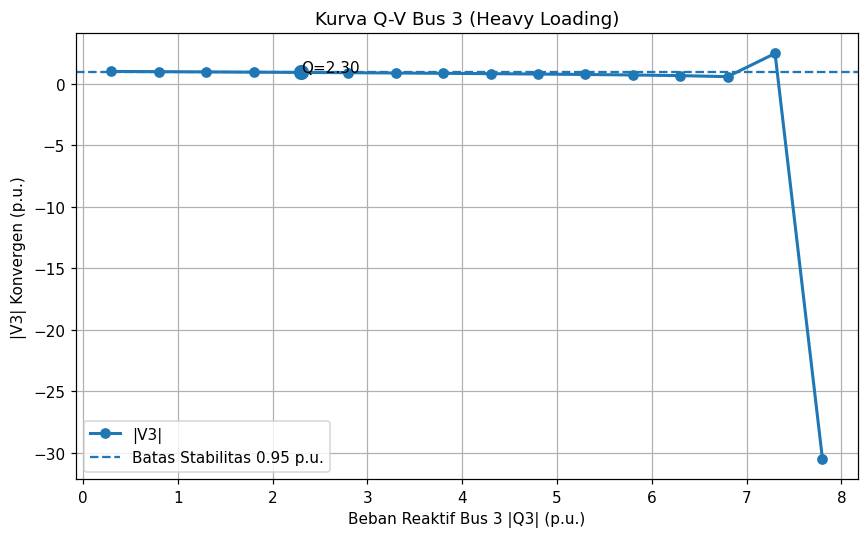

In [24]:
# === Pertanyaan G3 ===
# Heavy Loading Voltage Stability (Q-V Curve Bus 3)

q_id = 'G3'

import matplotlib.pyplot as plt

Q3_loads = np.arange(0.3, 8.1, 0.5)

V3_list = []
status_list = []

print("   Q3(p.u.)     |V3|      Status")
print("-"*35)

for q3 in Q3_loads:

    # Salin data asli
    Q_sch_test = Q_sch.copy()

    # Beban reaktif = negatif
    Q_sch_test[2] = -q3

    try:

        V_mag_sol_tmp, V_ang_sol_tmp, hist_inf_tmp, _, _ = (
            newton_raphson(
                V_mag.copy(),
                V_ang.copy(),
                Y_bus,
                P_sch,
                Q_sch_test,
                bus_type,
                epsilon=1e-4,
                max_iter=50
            )
        )

        V3 = V_mag_sol_tmp[2]

        V3_list.append(V3)
        status_list.append("Konvergen")

        print(f"{q3:10.2f}    {V3:8.4f}   Konvergen")

    except Exception:

        V3_list.append(np.nan)
        status_list.append("Divergen")

        print(f"{q3:10.2f}      ---      Divergen")


# ==================================================
# Titik kritis |V3| < 0.95 p.u.
# ==================================================

critical_Q = None

for q3, v3 in zip(Q3_loads, V3_list):

    if not np.isnan(v3) and v3 < 0.95:

        critical_Q = q3
        critical_V = v3
        break

print("\n" + "="*50)

if critical_Q is not None:

    print("Titik kritis ditemukan:")
    print(f"Q3 = {critical_Q:.2f} p.u.")
    print(f"|V3| = {critical_V:.4f} p.u.")

else:

    print("Sampai Q3 = 8.0 p.u. tegangan belum turun di bawah 0.95 p.u.")

# ==================================================
# Plot Kurva Q-V
# ==================================================

plt.figure(figsize=(8,5))

plt.plot(
    Q3_loads,
    V3_list,
    'o-',
    linewidth=2,
    markersize=6,
    label='|V3|'
)

plt.axhline(
    y=0.95,
    linestyle='--',
    linewidth=1.5,
    label='Batas Stabilitas 0.95 p.u.'
)

if critical_Q is not None:
    plt.scatter([critical_Q],[critical_V],s=80)
    plt.annotate(
        f'Q={critical_Q:.2f}',
        (critical_Q, critical_V)
    )

plt.xlabel('Beban Reaktif Bus 3 |Q3| (p.u.)')
plt.ylabel('|V3| Konvergen (p.u.)')
plt.title('Kurva Q-V Bus 3 (Heavy Loading)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

✅ Checklist Reproducibility (Wajib Sebelum Submit)

In [25]:
# ==================================================
# CHECKLIST AKHIR NOTEBOOK
# ==================================================

# Pastikan variabel neraca daya tersedia
try:
    P_beban
except NameError:
    P_beban = abs(P_sch[2]) + abs(P_sch[3])

try:
    P_gen_total
except NameError:
    P_gen_total = P_beban + P_loss

# Jacobian verifikasi
J_chk = build_jacobian(
    V_mag,
    np.zeros(n_bus),
    G,
    B,
    bus_type
)

J_num_chk = jacobian_numerical(
    V_mag,
    np.zeros(n_bus),
    G,
    B,
    bus_type
)

checks = {

    'Data kelompok terisi (tidak ada None)':
        (
            None not in P_sch.tolist()
            and None not in Q_sch.tolist()
            and None not in V_mag.tolist()
        ),

    'Y-Bus simetris':
        np.allclose(
            Y_bus,
            Y_bus.T,
            atol=1e-10
        ),

    'G_ii > 0':
        np.all(
            Y_bus.real.diagonal() > 0
        ),

    'Jacobian error < 1e-4':
        (
            np.max(
                np.abs(
                    J_chk - J_num_chk
                )
            ) < 1e-4
        ),

    'NR konvergen':
        (
            len(hist_inf) > 0
            and hist_inf[-1] < epsilon
        ),

    'Neraca daya OK':
        (
            abs(
                P_gen_total
                - P_beban
                - P_loss
            ) < 1e-4
        ),

    'Seed & nomor kelompok terisi':
        (
            SEED_KELOMPOK == 1009
            and NO_KELOMPOK is not None
        ),
}

all_pass = True

for item, status in checks.items():

    icon = '✅' if status else '❌'

    print(f'  {icon} {item}')

    if not status:
        all_pass = False

print()

if all_pass:

    print('🎉 Semua checklist lolos!')
    print('🎉 Notebook Seed 1009 siap dikumpulkan.')

else:

    print('⚠️ Ada checklist yang gagal.')
    print('⚠️ Periksa kembali sel yang belum lolos.')

  ✅ Data kelompok terisi (tidak ada None)
  ✅ Y-Bus simetris
  ✅ G_ii > 0
  ✅ Jacobian error < 1e-4
  ✅ NR konvergen
  ✅ Neraca daya OK
  ✅ Seed & nomor kelompok terisi

🎉 Semua checklist lolos!
🎉 Notebook Seed 1009 siap dikumpulkan.
